# 02 — Features EDA

4h-bin x stay long DataFrame produced by `src.features.build_features`.
Sanity-checks: shape, missingness, action distribution, time evolution, split integrity.

All plots are aggregate — no patient identifiers on axes/hover.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.cohort import load_cohort
from src.features import build_features, N_BINS
from src.splits import make_splits, save_splits

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

In [2]:
cohort = load_cohort()
features, stats = build_features(cohort=cohort, use_cache=True)
print(f'features shape: {features.shape}')
print(f'unique stays:   {features.stay_id.nunique()}  (cohort: {cohort.stay_id.nunique()})')
print(f't_bin range:    {features.t_bin.min()} .. {features.t_bin.max()}')
print(f'columns (first 25): {features.columns[:25].tolist()}')

features shape: (235278, 86)
unique stays:   13071  (cohort: 13071)
t_bin range:    0 .. 17
columns (first 25): ['stay_id', 'subject_id', 't_bin', 'next_ne_dose', 'next_ne_action_bin', 'ne_dose_now', 'hr_mean', 'hr_min', 'hr_max', 'hr_last', 'sbp_mean', 'sbp_min', 'sbp_max', 'sbp_last', 'dbp_mean', 'dbp_min', 'dbp_max', 'dbp_last', 'mbp_mean', 'mbp_min', 'mbp_max', 'mbp_last', 'rr_mean', 'rr_min', 'rr_max']


## 1. Missing-ness table
Raw missing-ness rates are captured by `*_was_missing` columns (pre-impute).
Threshold: highlight variables with >=30% raw missing.

In [3]:
raw_miss = pd.Series(stats['raw_missing_rate']).sort_values(ascending=False)
def _fmt(r: float) -> str:
    pct = r * 100
    mark = '  <-- HIGH' if r >= 0.30 else ''
    return f'{pct:5.1f}%{mark}'
print('raw missing rate (pre-ffill, among variables with _was_missing flag):')
for k, v in raw_miss.items():
    print(f'  {k:28s}  {_fmt(v)}')

raw missing rate (pre-ffill, among variables with _was_missing flag):
  inr_was_missing                78.9%  <-- HIGH
  ptt_was_missing                77.9%  <-- HIGH
  lactate_was_missing            77.5%  <-- HIGH
  wbc_was_missing                70.4%  <-- HIGH
  baseexcess_was_missing         66.9%  <-- HIGH
  ph_was_missing                 66.9%  <-- HIGH
  pco2_was_missing               66.9%  <-- HIGH
  po2_was_missing                66.9%  <-- HIGH
  sofa_was_missing               13.8%


In [4]:
# Post-impute missingness should be ~0 for numeric fill cols.
print('columns with any remaining NaN (should be empty):')
nans = features.isna().sum()
print(nans[nans > 0])

columns with any remaining NaN (should be empty):
Series([], dtype: int64)


## 2. Action distribution (next-bin NE-equiv)
5 bins: 0 / (0, 8.4] / (8.4, 20.28] / (20.28, 50] / >50 mcg/min NE-equiv.

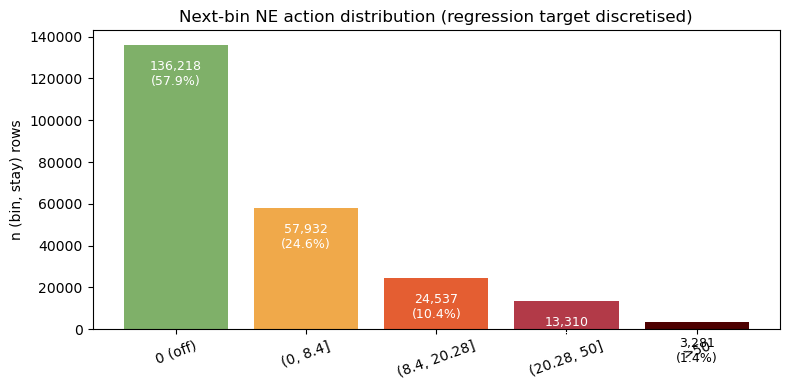

In [5]:
act_counts = features['next_ne_action_bin'].value_counts().sort_index()
labels = ['0 (off)', '(0, 8.4]', '(8.4, 20.28]', '(20.28, 50]', '>50']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(5), [act_counts.get(i, 0) for i in range(5)], color=['#7fb069', '#f0a94a', '#e45e32', '#b23a48', '#4d0000'])
ax.set_xticks(range(5))
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('n (bin, stay) rows')
ax.set_title('Next-bin NE action distribution (regression target discretised)')
for i, v in enumerate([act_counts.get(i, 0) for i in range(5)]):
    ax.text(i, v, f'\n{v:,}\n({v/act_counts.sum()*100:.1f}%)', ha='center', va='top', fontsize=9, color='white' if v > act_counts.sum()*0.05 else 'black')
plt.tight_layout()
plt.show()

## 3. Core variable distributions
Post-impute distributions. Outlier tails clipped for readability.

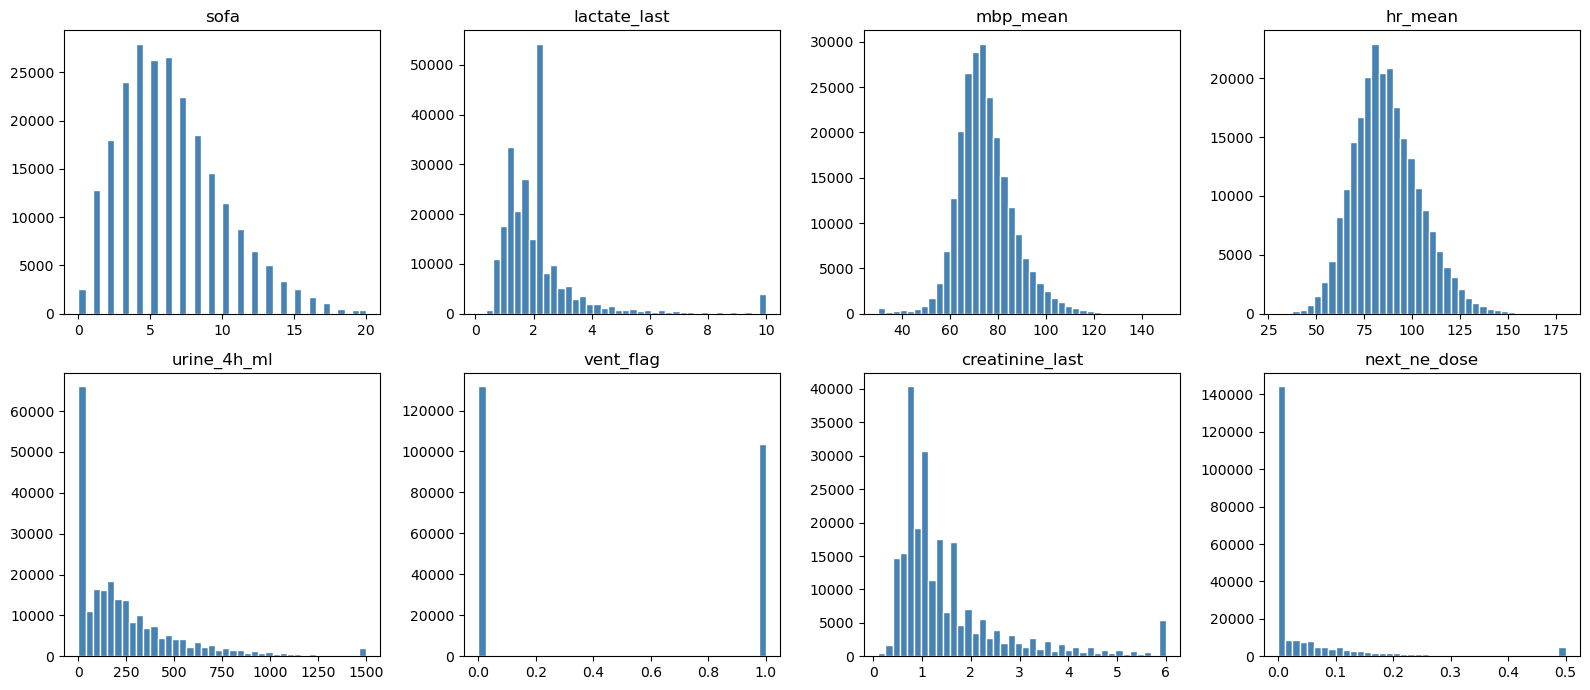

In [6]:
panel = [
    ('sofa', 0, 20),
    ('lactate_last', 0, 10),
    ('mbp_mean', 30, 150),
    ('hr_mean', 30, 180),
    ('urine_4h_ml', 0, 1500),
    ('vent_flag', None, None),
    ('creatinine_last', 0, 6),
    ('next_ne_dose', 0, 0.5),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (var, lo, hi) in zip(axes.ravel(), panel):
    if var not in features.columns:
        ax.set_title(f'{var} (missing)')
        continue
    data = features[var].dropna()
    if lo is not None:
        data = data.clip(lo, hi)
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(var)
plt.tight_layout()
plt.show()

## 4. Time evolution
Average SOFA, MAP, lactate, and vent-rate across the 18 bins.
Expectation: SOFA trends down after stabilisation, lactate clears, vent-rate highest early.

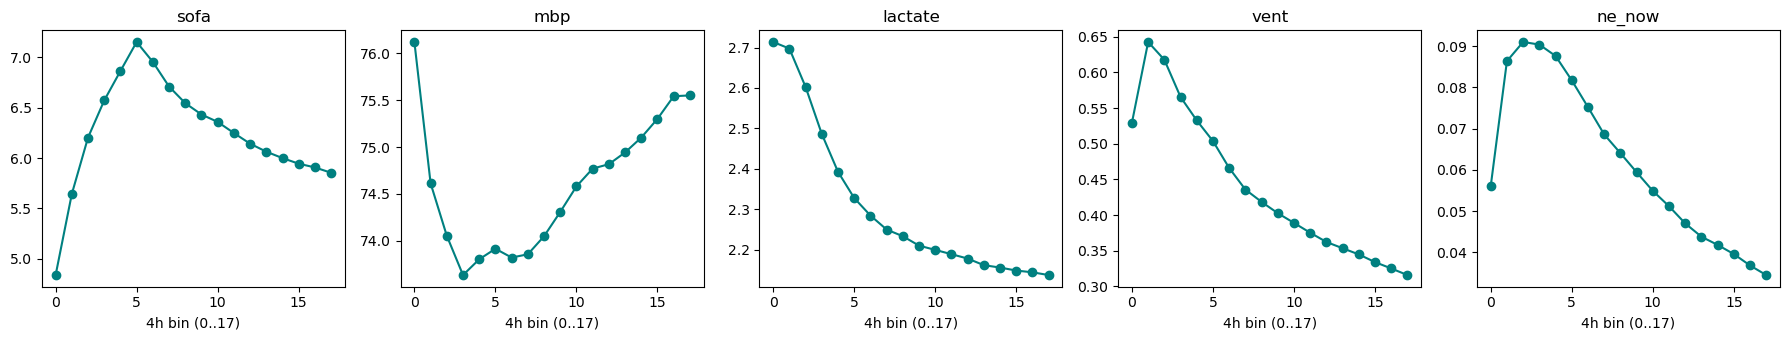

,sofa,mbp,lactate,vent,ne_now
t_bin,,,,,
0,4.835,76.121,2.714,0.530,0.056
1,5.643,74.613,2.697,0.643,0.086
2,6.203,74.053,2.603,0.618,0.091
3,6.573,73.634,2.486,0.565,0.090
4,6.866,73.803,2.393,0.533,0.088
5,7.154,73.915,2.328,0.504,0.082
6,6.956,73.821,2.285,0.466,0.075
7,6.711,73.856,2.250,0.436,0.069
8,6.546,74.048,2.234,0.418,0.064


In [7]:
agg = features.groupby('t_bin').agg(
    sofa=('sofa', 'mean'),
    mbp=('mbp_mean', 'mean'),
    lactate=('lactate_last', 'mean'),
    vent=('vent_flag', 'mean'),
    ne_now=('ne_dose_now', 'mean'),
)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, ['sofa', 'mbp', 'lactate', 'vent', 'ne_now']):
    ax.plot(agg.index, agg[col], marker='o', color='teal')
    ax.set_xlabel('4h bin (0..17)')
    ax.set_title(col)
plt.tight_layout()
plt.show()
agg.round(3)

## 5. Splits
Default = subject_random (prevents within-patient leakage).
Expected ≈ 70/15/15.

In [8]:
splits = make_splits(cohort, strategy='subject_random', seed=42)
save_splits(splits, cohort, strategy='subject_random')
for k, v in splits.items():
    frac = len(v) / len(cohort) * 100
    print(f'{k:5s}: {len(v):>6,} stays ({frac:5.1f}%)')

train:  9,149 stays ( 70.0%)
val  :  1,961 stays ( 15.0%)
test :  1,961 stays ( 15.0%)


In [9]:
# Leakage check: no subject appears in more than one fold.
stay_to_subj = dict(zip(cohort['stay_id'].astype(int), cohort['subject_id'].astype(int)))
subj_sets = {k: {stay_to_subj[int(s)] for s in v} for k, v in splits.items()}
for a in ('train', 'val', 'test'):
    for b in ('train', 'val', 'test'):
        if a < b:
            inter = subj_sets[a] & subj_sets[b]
            print(f'{a} <-> {b}: overlap = {len(inter)} subjects (must be 0)')

train <-> val: overlap = 0 subjects (must be 0)
test <-> train: overlap = 0 subjects (must be 0)
test <-> val: overlap = 0 subjects (must be 0)


In [10]:
# Stratification sanity: demographics/mortality roughly balanced across folds?
cohort_by_fold = []
for k, stays in splits.items():
    sub = cohort[cohort['stay_id'].isin(stays)]
    cohort_by_fold.append({
        'fold': k,
        'n': len(sub),
        'age_mean': round(sub['age'].mean(), 1),
        'male_frac': round((sub['gender'] == 'M').mean(), 3),
        'mortality': round(sub['hospital_expire_flag'].mean(), 3),
        'mean_peak_ne': round(sub['peak_ne_equiv'].mean(), 4),
    })
pd.DataFrame(cohort_by_fold)

,fold,n,age_mean,male_frac,mortality,mean_peak_ne
0,train,9149,67.1,0.595,0.231,0.6129
1,val,1961,67.1,0.596,0.237,0.7551
2,test,1961,67.3,0.616,0.225,0.5707


---

**Next (supervised-model-agent)**: load `data/features_v1.parquet` + `data/splits_v1.json`, fit encoder ablation (MLP last-bin, MLP aggregated, LSTM, small Transformer).